In [1]:
!pip install py_vollib_vectorized

In [5]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from py_vollib_vectorized import vectorized_implied_volatility as implied_vol
import scipy.stats as stats
import pandas as pd

In [46]:
#https://github.com/Pauli-Isosomppi/Heston-model/blob/main/Heston%20model.ipynb source
 #Parameters
# simulation dependent
S0 = 100.0             # asset price
T = 1.0                # time in years
r = 0.02               # risk-free rate
N = 250                # number of time steps in simulation
M = 10000               # number of simulations

# Heston dependent parameters
kappa = 2              # rate of mean reversion of variance under risk-neutral dynamics
theta = 0.20**2        # long-term mean of variance under risk-neutral dynamics
v0 = 0.04           # initial variance under risk-neutral dynamics
rho = -0.7              # correlation between returns and variances under risk-neutral dynamics
sigma = 0.5            # volatility of volatility


#TASK 6
Feller codnition 2kθ > σ^2. for uds kappa = 2, theta = 0.04 and sigma 0.5

Feller Condition: 2*kappa*theta (0.16) vs sigma^2 (0.25)
--> Feller condition is VIOLATED. Variance may touch zero.
--> During the simulation, the variance calculation attempted to become negative 24523 times in total.
--> 5585 paths out of 10000 attempted to take negative values at least once.


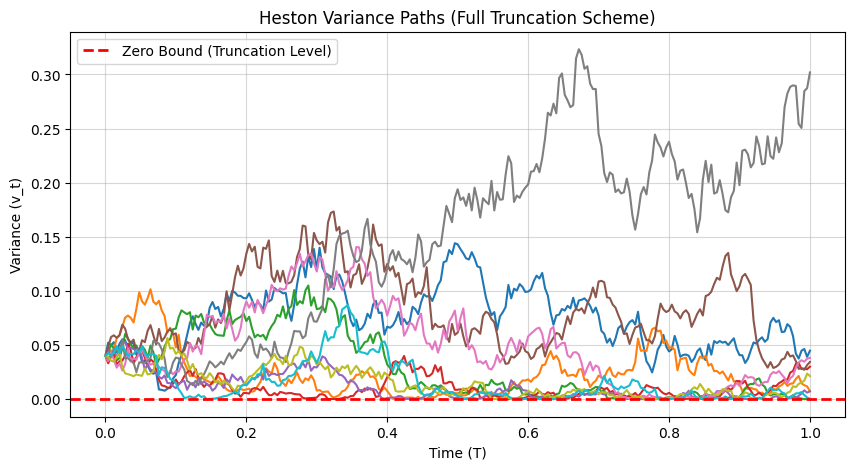

In [67]:
import numpy as np
import matplotlib.pyplot as plt

dt = T / N

#Verify Feller conditions
feller_val = 2 * kappa * theta
sigma_sq = sigma**2
print(f"Feller Condition: 2*kappa*theta ({feller_val:.2f}) vs sigma^2 ({sigma_sq:.2f})")
if feller_val < sigma_sq:
    print("--> Feller condition is VIOLATED. Variance may touch zero.")

# --- Variance Simulation (Task 6) ---
# Initialize the variance matrix
v = np.zeros((N + 1, M))
v[0] = v0

# Generate random numbers (Z_v)
Z_v = np.random.standard_normal((N, M))

# Counter to see how many times the variance would attempt to go negative
negative_attempts_count = 0
# A boolean array to keep track of which paths have gone negative at least once
paths_with_negative_attempt = np.zeros(M, dtype=bool)

for t in range(N):
    # Apply max(v, 0) for drift and diffusion (full truncation)
    v_plus = np.maximum(v[t], 0)

    # Calculate the next Euler step without final truncation
    v_next_untruncated = v[t] + kappa * (theta - v_plus) * dt + sigma * np.sqrt(v_plus) * np.sqrt(dt) * Z_v[t]

    # Identify which paths attempted to go negative in this step
    negative_this_step = (v_next_untruncated < 0)
    negative_attempts_count += np.sum(negative_this_step)

    # Update the boolean array to mark paths that have attempted to go negative at least once
    paths_with_negative_attempt = np.logical_or(paths_with_negative_attempt, negative_this_step)

    # Apply final truncation for the next step
    v[t+1] = np.maximum(v_next_untruncated, 0)

print(f"--> During the simulation, the variance calculation attempted to become negative {negative_attempts_count} times in total.")
print(f"--> {np.sum(paths_with_negative_attempt)} paths out of {M} attempted to take negative values at least once.")


# --- Plotting some paths ---
plt.figure(figsize=(10, 5))
# Plot the first 10 paths to see the behavior near zero
plt.plot(np.linspace(0, T, N+1), v[:, :10], lw=1.5)

# Add a red line at zero to highlight the boundary
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Bound (Truncation Level)')

plt.title('Heston Variance Paths (Full Truncation Scheme)')
plt.xlabel('Time (T)')
plt.ylabel('Variance (v_t)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [113]:
def heston_model_sim(S0, v0, rho, kappa, theta, sigma,T, N, M):
    """
    Inputs:
     - S0, v0: initial parameters for asset and variance
     - rho   : correlation between asset returns and variance
     - kappa : rate of mean reversion in variance process
     - theta : long-term mean of variance process
     - sigma : vol of vol / volatility of variance process
     - T     : time of simulation
     - N     : number of time steps
     - M     : number of scenarios / simulations

    Outputs:
    - asset prices over time (numpy array)
    - variance over time (numpy array)
    """
    # initialise other parameters
    dt = T/N
    mu = np.array([0,0])
    cov = np.array([[1,rho],
                    [rho,1]])

    # arrays for storing prices and variances
    S = np.full(shape=(N+1,M), fill_value=S0)
    v = np.full(shape=(N+1,M), fill_value=v0)

    # sampling correlated brownian motions under risk-neutral measure
    Z = np.random.multivariate_normal(mu, cov, (N,M))

    for i in range(1,N+1):
        v_t=np.maximum(v[i-1],0)
        S[i] = S[i-1] * np.exp( (r - 0.5*v_t)*dt + np.sqrt(v_t * dt) * Z[i-1,:,0] )
        v[i] = v[i-1]+ kappa*(theta-v_t)*dt + sigma*np.sqrt(v_t*dt)*Z[i-1,:,1] #full truncation

    return S, v

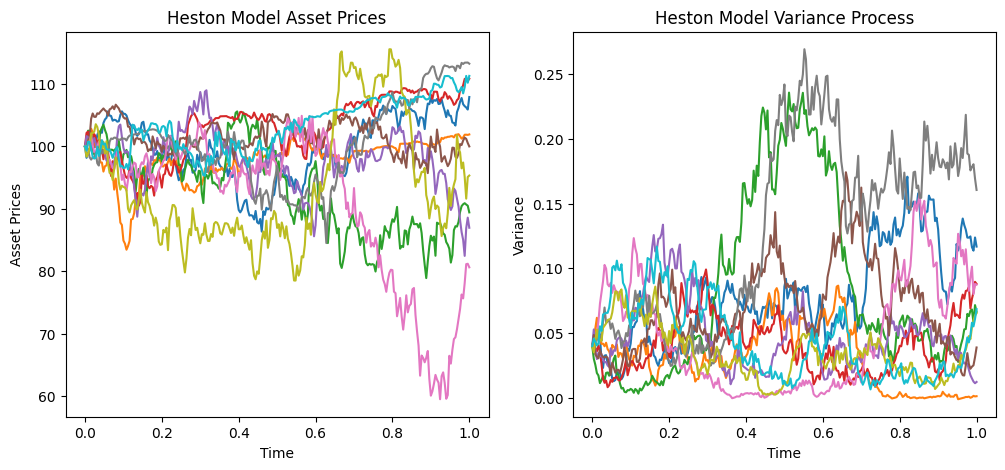

In [114]:

rho_p = 0.7
rho_n = -0.7
S_p,v_p = heston_model_sim(S0, v0, rho_p, kappa, theta, sigma,T, N, M)
S_n,v_n = heston_model_sim(S0, v0, rho_n, kappa, theta, sigma,T, N, M)
fig, (ax1, ax2)  = plt.subplots(1, 2, figsize=(12,5))
time = np.linspace(0,T,N+1)
ax1.plot(time,S_n[:, :10]) # Plotting only the first 10 paths
ax1.set_title('Heston Model Asset Prices')
ax1.set_xlabel('Time')
ax1.set_ylabel('Asset Prices')

ax2.plot(time,v_p[:, :10]) # Plotting only the first 10 paths
ax2.set_title('Heston Model Variance Process')
ax2.set_xlabel('Time')
ax2.set_ylabel('Variance')

plt.show()

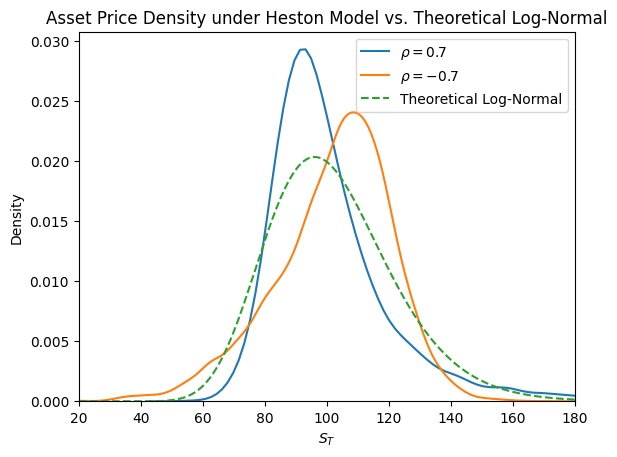

In [99]:
# Calculate parameters for theoretical log-normal distribution
vol_gbm = np.sqrt(v0) # Using long-term variance from Heston as a proxy for GBM volatility
mu_lognormal = np.log(S0) + (r - 0.5 * vol_gbm**2) * T
sigma_lognormal = vol_gbm * np.sqrt(T)

# Generate x values for the density plot
x = np.linspace(20, 180, 500)

# Calculate the theoretical log-normal PDF
theoretical_density = stats.lognorm.pdf(x, s=sigma_lognormal, scale=np.exp(mu_lognormal))

fig, ax = plt.subplots()

ax = sns.kdeplot(S_p[-1], label=r"$\rho= 0.7$", ax=ax)
ax = sns.kdeplot(S_n[-1], label=r"$\rho= -0.7$", ax=ax)
ax.plot(x, theoretical_density, label="Theoretical Log-Normal", linestyle='--') # Plotting the theoretical density

plt.title(r'Asset Price Density under Heston Model vs. Theoretical Log-Normal')
plt.xlim([20, 180])
plt.xlabel('$S_T$')
plt.ylabel('Density')
plt.legend()
plt.show()

In [100]:
from scipy.stats import skew, kurtosis

print("\n--- Statistics at time T ---")

# Heston with positive rho
mean_sp = np.mean(S_p[-1])
std_sp = np.std(S_p[-1])
skew_sp = skew(S_p[-1])
kurt_sp = kurtosis(S_p[-1])
print(f"Heston (rho = {rho_p}):\n  Mean: {mean_sp:.4f}\n  Standard Deviation: {std_sp:.4f}\n  Skewness: {skew_sp:.4f}")

# Heston with negative rho
mean_sn = np.mean(S_n[-1])
std_sn = np.std(S_n[-1])
skew_sn = skew(S_n[-1])
kurt_sn = kurtosis(S_n[-1])
print(f"Heston (rho = {rho_n}):\n  Mean: {mean_sn:.4f}\n  Standard Deviation: {std_sn:.4f}\n  Skewness: {skew_sn:.4f}")

# Theoretical Log-Normal (Black-Scholes equivalent)
theo_mean = stats.lognorm.mean(s=sigma_lognormal, scale=np.exp(mu_lognormal))
theo_std = stats.lognorm.std(s=sigma_lognormal, scale=np.exp(mu_lognormal))
theo_skew = stats.lognorm.stats(s=sigma_lognormal, scale=np.exp(mu_lognormal), moments='s') # 's' for skewness
theo_kurt = stats.lognorm.stats(s=sigma_lognormal, scale=np.exp(mu_lognormal), moments='k')
print(f"Theoretical Log-Normal:\n  Mean: {theo_mean:.4f}\n  Standard Deviation: {theo_std:.4f}\n  Skewness: {theo_skew:.4f}\n Kurtosis: {theo_kurt:.4f}")


--- Statistics at time T ---
Heston (rho = 0.7):
  Mean: 101.6612
  Standard Deviation: 22.2582
  Skewness: 2.7246
Heston (rho = -0.7):
  Mean: 102.1515
  Standard Deviation: 18.9552
  Skewness: -0.6223
Theoretical Log-Normal:
  Mean: 102.0201
  Standard Deviation: 20.6098
  Skewness: 0.6143
 Kurtosis: 0.6784


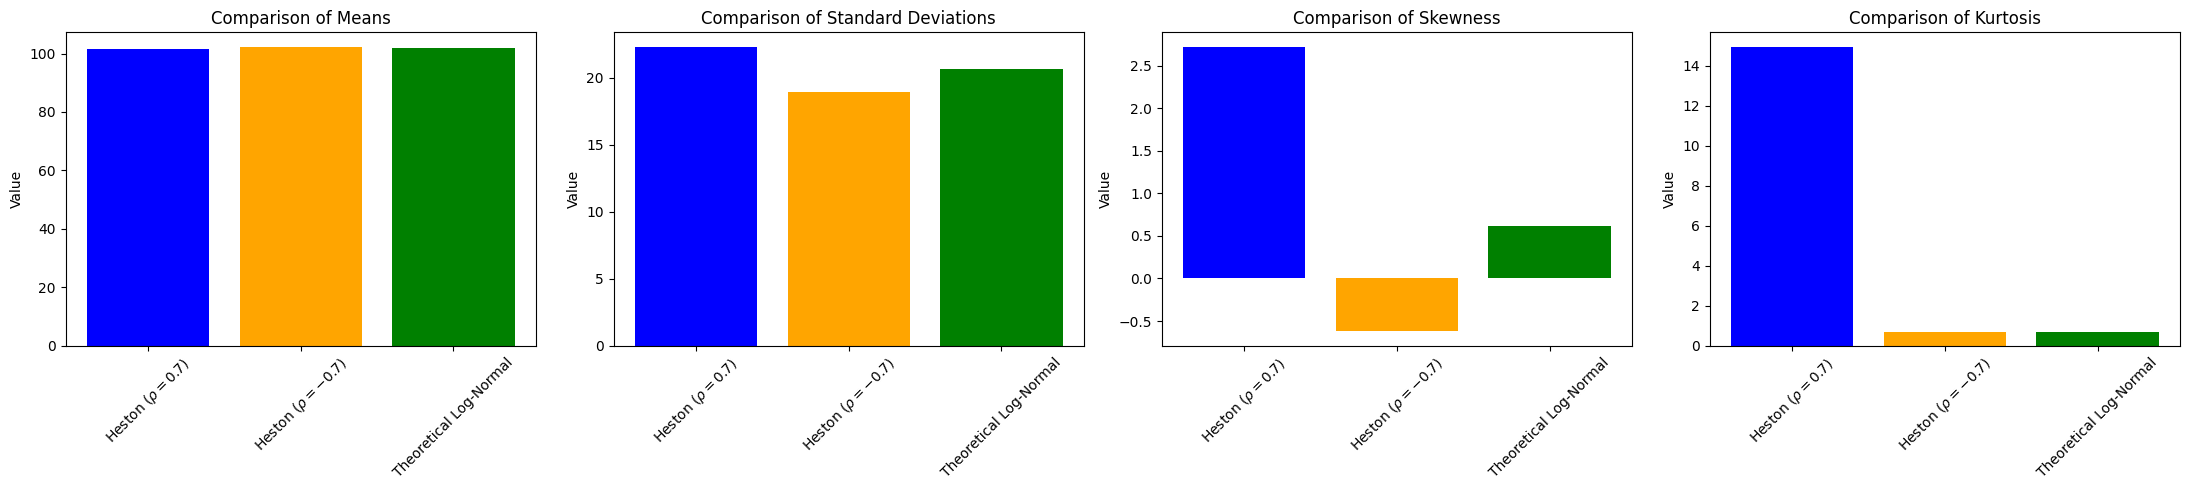

,Heston (rho_p),Heston (rho_n),Theoretical Log-Normal
Metric,,,
Mean,101.661243,102.151485,102.020134
Standard Deviation,22.258155,18.955154,20.609778
Skewness,2.724597,-0.622259,0.614295
Kurtosis,14.920215,0.672201,0.678366


In [101]:
labels = [rf'Heston ($\rho={rho_p}$)', rf'Heston ($\rho={rho_n}$)', 'Theoretical Log-Normal']
means = [mean_sp, mean_sn, theo_mean]
stds = [std_sp, std_sn, theo_std]
skews = [skew_sp, skew_sn, theo_skew]
kurts = [kurt_sp, kurt_sn, theo_kurt]

metrics_df = pd.DataFrame({
    'Metric': ['Mean', 'Standard Deviation', 'Skewness', 'Kurtosis'],
    'Heston (rho_p)': [mean_sp, std_sp, skew_sp, kurt_sp],
    'Heston (rho_n)': [mean_sn, std_sn, skew_sn, kurt_sn],
    'Theoretical Log-Normal': [theo_mean, theo_std, theo_skew, theo_kurt]
}).set_index('Metric')

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Bar plot for Mean
axes[0].bar(labels, means, color=['blue', 'orange', 'green'])
axes[0].set_title('Comparison of Means')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=45)

# Bar plot for Standard Deviation
axes[1].bar(labels, stds, color=['blue', 'orange', 'green'])
axes[1].set_title('Comparison of Standard Deviations')
axes[1].set_ylabel('Value')
axes[1].tick_params(axis='x', rotation=45)

# Bar plot for Skewness
axes[2].bar(labels, skews, color=['blue', 'orange', 'green'])
axes[2].set_title('Comparison of Skewness')
axes[2].set_ylabel('Value')
axes[2].tick_params(axis='x', rotation=45)

# Bar plot for Kurtosis
axes[3].bar(labels, kurts, color=['blue', 'orange', 'green'])
axes[3].set_title('Comparison of Kurtosis')
axes[3].set_ylabel('Value')
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

display(metrics_df)

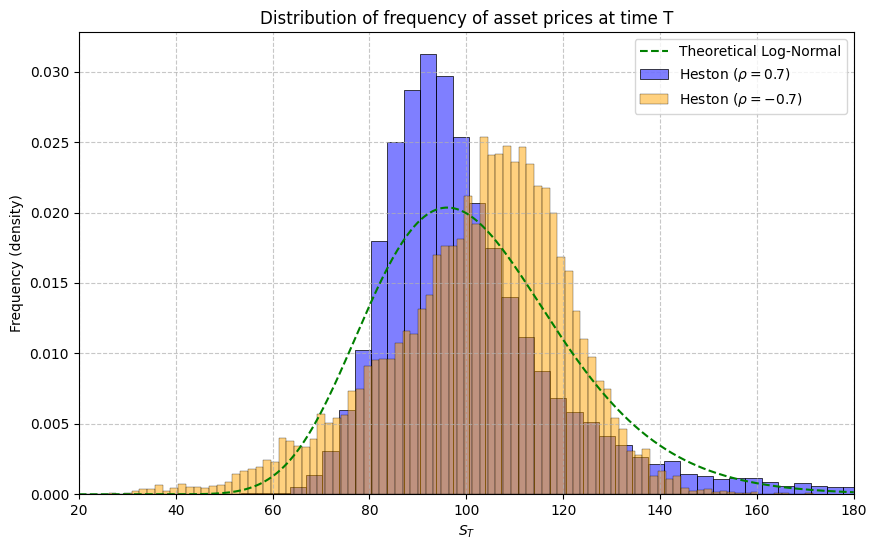

In [102]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(S_p[-1], bins=100, kde=False, stat='density', alpha=0.5, label=rf'Heston ($\rho= {rho_p}$)', color='blue', ax=ax)
sns.histplot(S_n[-1], bins=100, kde=False, stat='density', alpha=0.5, label=rf'Heston ($\rho= {-0.7}$)', color='orange', ax=ax)


x = np.linspace(20, 180, 500)
theoretical_density = stats.lognorm.pdf(x, s=sigma_lognormal, scale=np.exp(mu_lognormal))
ax.plot(x, theoretical_density, label="Theoretical Log-Normal", linestyle='--', color='green')

ax.set_title('Distribution of frequency of asset prices at time T')
ax.set_xlabel('$S_T$')
ax.set_ylabel('Frequency (density)')
ax.legend()
ax.set_xlim([20, 180])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#TASK 3

In [103]:
from scipy.stats import norm


for i in range(90,111,10):
  strike_price = i # ATM option

#computation of price using MC
  call_payoff_mc = np.maximum(S_n[-1] - strike_price, 0)
  call_price_mc = np.exp(-r * T) * np.mean(call_payoff_mc)

  #price with black scholes
  volatility_bs = sigma_lognormal # Volatility for Black-Scholes

  d1 = (np.log(S0 / strike_price) + (r + 0.5 * volatility_bs**2) * T) / (volatility_bs * np.sqrt(T))
  d2 = d1 - volatility_bs * np.sqrt(T)

  call_price_bs = (S0 * norm.cdf(d1) - strike_price * np.exp(-r * T) * norm.cdf(d2))

  print(f"Prezzo Call Monte Carlo (Heston): {call_price_mc:.4f}")
  print(f"Prezzo Call Black-Scholes (vol = {volatility_bs:.4f}): {call_price_bs:.4f}")

Prezzo Call Monte Carlo (Heston): 15.2567
Prezzo Call Black-Scholes (vol = 0.2000): 14.8065
Prezzo Call Monte Carlo (Heston): 8.4784
Prezzo Call Black-Scholes (vol = 0.2000): 8.9160
Prezzo Call Monte Carlo (Heston): 3.6637
Prezzo Call Black-Scholes (vol = 0.2000): 4.9439


#TASK 4

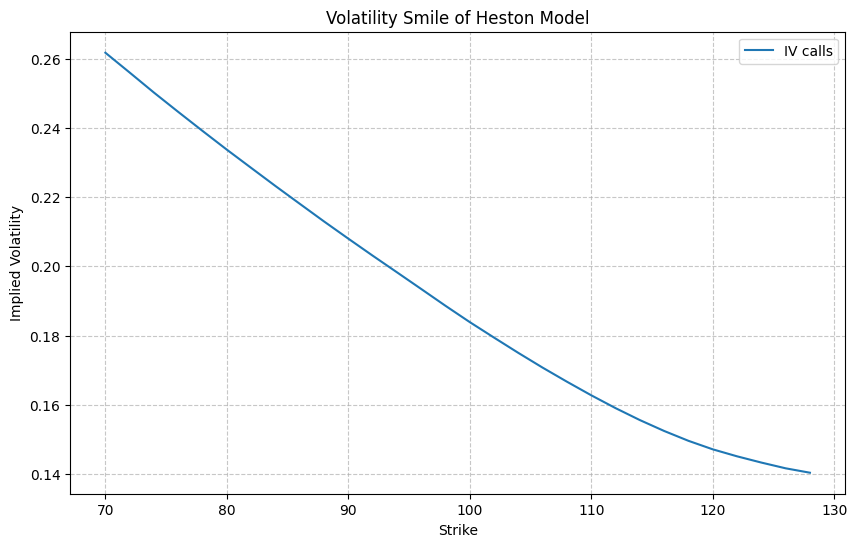

In [93]:
rho = -0.7
S,v = heston_model_sim(S0, v0, rho, kappa, theta, sigma,T, N, M)

# Set strikes and complete MC option price for different strikes
K = np.arange(70,130,2)


calls = np.array([np.exp(-r*T)*np.mean(np.maximum(S[-1]-k,0)) for k in K])


call_ivs = implied_vol(calls, S0, K, T, r, flag='c', q=0, return_as='numpy', on_error='ignore')

plt.figure(figsize=(10,6))
plt.plot(K, call_ivs, label=r'IV calls')


plt.ylabel('Implied Volatility')
plt.xlabel('Strike')

plt.title('Volatility Smile of Heston Model')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#TASK 5

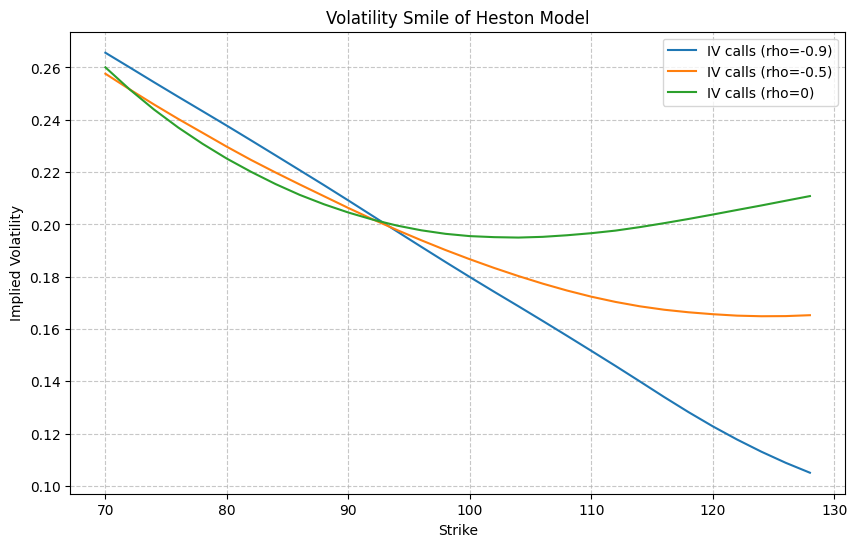

In [105]:
l=[-0.9,-0.5,0]
plt.figure(figsize=(10,6))
for i in l:
  rho=i
  S,v = heston_model_sim(S0, v0, rho, kappa, theta, sigma,T, N, M)

  # Set strikes and complete MC option price for different strikes
  K = np.arange(70,130,2)


  calls = np.array([np.exp(-r*T)*np.mean(np.maximum(S[-1]-k,0)) for k in K])


  call_ivs = implied_vol(calls, S0, K, T, r, flag='c', q=0, return_as='numpy', on_error='ignore')


  plt.plot(K, call_ivs, label=rf'IV calls (rho={rho})')


plt.ylabel('Implied Volatility')
plt.xlabel('Strike')

plt.title('Volatility Smile of Heston Model')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
rho = -0.7

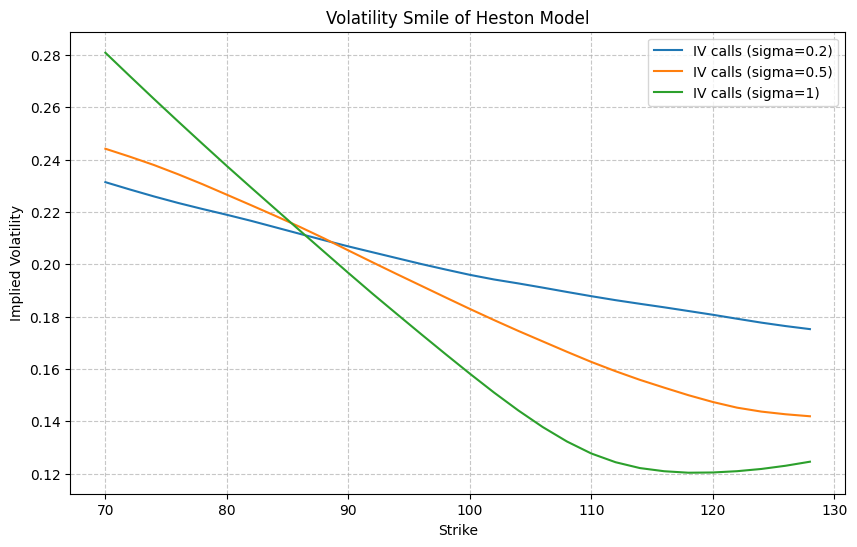

In [106]:

l = [0.2,0.5,1]
plt.figure(figsize=(10,6))

for i in l:
  sigma=i
  S,v = heston_model_sim(S0, v0, rho, kappa, theta, sigma,T, N, M)

  # Set strikes and complete MC option price for different strikes
  K = np.arange(70,130,2)


  calls = np.array([np.exp(-r*T)*np.mean(np.maximum(S[-1]-k,0)) for k in K])


  call_ivs = implied_vol(calls, S0, K, T, r, flag='c', q=0, return_as='numpy', on_error='ignore')


  plt.plot(K, call_ivs, label=rf'IV calls (sigma={sigma})')


plt.ylabel('Implied Volatility')
plt.xlabel('Strike')

plt.title('Volatility Smile of Heston Model')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

sigma = 0.5

#TASK 7

In [115]:
#https://github.com/cantaro86/Financial-Models-Numerical-Methods/blob/master/1.4%20SDE%20-%20Heston%20model.ipynb source


S0 = 100.0
r = 0.02
T = 1.0
kappa = 2.0
theta = 0.04
sigma = 0.5
rho = -0.7
v0 = 0.04

def heston_cf(u, S0, v0, r, kappa, theta, sigma, rho, T):
    """
    Calculates the characteristic function of the log-price in the Heston model.
    """
    i = 1j # Imaginary unit

    # Calculation of d and g
    d = np.sqrt((kappa - i * rho * sigma * u)**2 + sigma**2 * (i * u + u**2))
    g = (kappa - i * rho * sigma * u - d) / (kappa - i * rho * sigma * u + d)

    # Calculation of affine components C and D
    C = r * i * u * T + (kappa * theta / sigma**2) * (
        (kappa - i * rho * sigma * u - d) * T - 2 * np.log((1 - g * np.exp(-d * T)) / (1 - g))
    )
    D = ((kappa - i * rho * sigma * u - d) / sigma**2) * ((1 - np.exp(-d * T)) / (1 - g * np.exp(-d * T)))

    # Final value of the Characteristic Function phi(u)
    phi = np.exp(C + D * v0 + i * u * np.log(S0))
    return phi


def integrand_P1(u, S0, K, v0, r, kappa, theta, sigma, rho, T):
    i = 1j
    # For P1 we evaluate phi(u - i)
    phi_num = heston_cf(u - i, S0, v0, r, kappa, theta, sigma, rho, T)
    # phi(-i) theoretically equals E[S_T] = S0 * exp(r*T)
    phi_den = S0 * np.exp(r * T)

    val = np.exp(-i * u * np.log(K)) * phi_num / (i * u * phi_den)
    return val.real

def integrand_P2(u, S0, K, v0, r, kappa, theta, sigma, rho, T):
    i = 1j
    phi = heston_cf(u, S0, v0, r, kappa, theta, sigma, rho, T)
    val = np.exp(-i * u * np.log(K)) * phi / (i * u)
    return val.real

def simpson_integration(func, a, b, N, args):
    """
    Manual implementation of integration using Simpson's Method.
    N must be an even number.
    """
    if N % 2 != 0:
        N += 1 # Ensure N is even

    x = np.linspace(a, b, N + 1)
    h = (b - a) / N
    y = np.array([func(xi, *args) for xi in x])

    # Simpson's formula: h/3 * (y[0] + 4*y[odd] + 2*y[even] + y[N])
    S = y[0] + y[-1]
    S += 4 * np.sum(y[1:-1:2])
    S += 2 * np.sum(y[2:-2:2])

    return (h / 3) * S


def heston_call_price(S0, K, v0, r, kappa, theta, sigma, rho, T):
    # Integration limits (start from 1e-5 to avoid division by zero)
    a = 1e-5
    b = 100.0  # Approximation of infinity
    N = 1000   # Number of sub-intervals for Simpson

    args = (S0, K, v0, r, kappa, theta, sigma, rho, T)

    # Numerically integrate
    int_P1 = simpson_integration(integrand_P1, a, b, N, args)
    int_P2 = simpson_integration(integrand_P2, a, b, N, args)

    # Calculate pseudo-probabilities P1 and P2
    P1 = 0.5 + (1 / np.pi) * int_P1
    P2 = 0.5 + (1 / np.pi) * int_P2

    # Exact pricing formula (similar to Black-Scholes)
    call_price = S0 * P1 - K * np.exp(-r * T) * P2
    return call_price

# --- TEST THE CODE ON THE 3 STRIKES FROM TASK 3 ---


print("--- Analytical and Monte Carlo Heston Call Prices (Task 7) ---")
for K_strike in range(80,121,10):
    # Analytical Heston Call Price
    analytical_price = heston_call_price(S0, K_strike, v0, r, kappa, theta, sigma, rho, T)

    # Monte Carlo Heston Call Price (using S_n from previous simulation with rho = -0.7)
    call_payoff_mc = np.maximum(S_n[-1] - K_strike, 0)
    mc_price = np.exp(-r * T) * np.mean(call_payoff_mc)
    error = abs(analytical_price-mc_price)

    print(f"Strike K = {K_strike:3d} | Analytical Price = {analytical_price:6.3f} | MC Price = {mc_price:6.3f} | Abs Error = {error:6.3f}")

--- Analytical and Monte Carlo Heston Call Prices (Task 7) ---
Strike K =  80 | Analytical Price = 23.188 | MC Price = 23.256 | Abs Error =  0.068
Strike K =  90 | Analytical Price = 15.092 | MC Price = 15.179 | Abs Error =  0.087
Strike K = 100 | Analytical Price =  8.336 | MC Price =  8.428 | Abs Error =  0.092
Strike K = 110 | Analytical Price =  3.571 | MC Price =  3.657 | Abs Error =  0.086
Strike K = 120 | Analytical Price =  1.107 | MC Price =  1.181 | Abs Error =  0.074
